In [79]:
# Import Python Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
#Load datasets
df1 = pd.read_csv('/content/Cyclist_Analyst_Case_Study_2020.csv')
df2 = pd.read_csv('/content/Divvy_Trips_2019_Q1.csv')

In [56]:
#Check df1 dataset columns
#Did this to know if i should merge the dataset)
df1.columns



Index(['ride_id', 'rideable_type', 'started_at', 'ended_at', 'ride_length',
       'day_of_week', 'start_station_name', 'start_station_id',
       'end_station_name', 'end_station_id', 'start_lat', 'start_lng',
       'end_lat', 'end_lng', 'member_casual'],
      dtype='object')

In [57]:
# Check the df1 number of rows and columns
df1.shape

(426889, 15)

In [58]:
# Check the df2 number of rows and columns
df2.shape

(365069, 12)

In [59]:
#Check df2 dataset columns ( Did this to know if i should merge the dataset with df1 dataset)
df2.columns


Index(['trip_id', 'start_time', 'end_time', 'bikeid', 'tripduration',
       'from_station_id', 'from_station_name', 'to_station_id',
       'to_station_name', 'usertype', 'gender', 'birthyear'],
      dtype='object')

In [60]:
#Identifying columns present in df1 but not in df2
set(df1.columns) - set(df2.columns)

{'day_of_week',
 'end_lat',
 'end_lng',
 'end_station_id',
 'end_station_name',
 'ended_at',
 'member_casual',
 'ride_id',
 'ride_length',
 'rideable_type',
 'start_lat',
 'start_lng',
 'start_station_id',
 'start_station_name',
 'started_at'}

In [61]:
#Identifying columns present in df2 but not in df1
set(df2.columns) - set(df1.columns)

{'bikeid',
 'birthyear',
 'end_time',
 'from_station_id',
 'from_station_name',
 'gender',
 'start_time',
 'to_station_id',
 'to_station_name',
 'trip_id',
 'tripduration',
 'usertype'}

In [62]:
#Renaming old dataset columns
df2 = df2.rename(columns={
    'trip_id': 'ride_id',
    'start_time': 'started_at',
    'end_time': 'ended_at',
    'from_station_id': 'start_station_id',
    'from_station_name': 'start_station_name',
    'to_station_id': 'end_station_id',
    'to_station_name': 'end_station_name',
    'usertype': 'member_casual'
})

In [63]:
# Define the shared columns that exist in both datasets
# This ensures the datasets have the same structure before combining
#and prepares the dataframe for concatenation.
common_cols = [
    'ride_id',
    'started_at',
    'ended_at',
    'start_station_id',
    'start_station_name',
    'end_station_id',
    'end_station_name',
    'member_casual'
]

In [64]:
# Create new dataframes that contain only the shared columns
# This ensures both datasets have identical structure before merging
df1_aligned = df1[common_cols].copy()
df2_aligned = df2[common_cols].copy()

In [65]:
#merging both dataframe
df = pd.concat([df1_aligned, df2_aligned], ignore_index=True)

In [66]:
#Verify merged data
df.head()
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791958 entries, 0 to 791957
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             791956 non-null  object 
 1   started_at          791956 non-null  object 
 2   ended_at            791956 non-null  object 
 3   start_station_id    791956 non-null  float64
 4   start_station_name  791956 non-null  object 
 5   end_station_id      791955 non-null  float64
 6   end_station_name    791955 non-null  object 
 7   member_casual       791956 non-null  object 
dtypes: float64(2), object(6)
memory usage: 48.3+ MB


,0
ride_id,2
started_at,2
ended_at,2
start_station_id,2
start_station_name,2
end_station_id,3
end_station_name,3
member_casual,2


In [67]:
#Create useful variables
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])
df['ride_length'] = df['ended_at'] - df['started_at']
df['day_of_week'] = df['started_at'].dt.day_name()

In [68]:
#Inspect the ride_length data
df['ride_length'].describe()

,ride_length
count,791956
mean,0 days 00:19:43.813276242
std,0 days 09:13:32.741229653
min,-1 days +23:50:48
25%,0 days 00:05:28
50%,0 days 00:08:57
75%,0 days 00:15:10
max,123 days 01:20:22


In [69]:
#Removing -ve ride_lengths
# Remove rides where the end time occurs before the start time
df = df[df['ride_length'] > pd.Timedelta(seconds=0)]



In [70]:
#Remove rides longer than 24 hours
df = df[df['ride_length'] < pd.Timedelta(hours=24)]

In [71]:
df['ride_length'].describe()

,ride_length
count,791264
mean,0 days 00:13:39.716940237
std,0 days 00:31:03.295850169
min,0 days 00:00:01
25%,0 days 00:05:28
50%,0 days 00:08:57
75%,0 days 00:15:09
max,0 days 23:55:55


In [72]:
# Convert ride duration to minutes
df['ride_length_minutes'] = df['ride_length'].dt.total_seconds() / 60


In [73]:
# Standardize rider type labels across both datasets
df['member_casual'] = df['member_casual'].replace({
    'Subscriber': 'member',
    'Customer': 'casual'
})

In [74]:
#Do casual members ride longer than members?
df.groupby('member_casual')['ride_length_minutes'].mean()


,ride_length_minutes
member_casual,
casual,36.463201
member,11.409516


In [75]:
#Busiest days of the week?
df['day_of_week'].value_counts()
#

,count
day_of_week,
Tuesday,135895
Thursday,132927
Wednesday,130207
Friday,123598
Monday,117084
Sunday,78756
Saturday,72797


In [76]:
# Compare ride counts by day of week and rider type
df.groupby(['day_of_week', 'member_casual'])['ride_id'].count()

day_of_week  member_casual
Friday       casual             8466
             member           115132
Monday       casual             6672
             member           110412
Saturday     casual            13416
             member            59381
Sunday       casual            18578
             member            60178
Thursday     casual             7729
             member           125198
Tuesday      casual             7949
             member           127946
Wednesday    casual             8328
             member           121879
Name: ride_id, dtype: int64

In [77]:
#Do casual riders ride longer specifically on weekends?
df.groupby(['day_of_week', 'member_casual'])['ride_length_minutes'].mean()
#

day_of_week  member_casual
Friday       casual           34.957524
             member           11.101253
Monday       casual           28.745891
             member           11.104777
Saturday     casual           38.945682
             member           12.435637
Sunday       casual           40.857169
             member           12.920790
Thursday     casual           32.427395
             member           11.069124
Tuesday      casual           32.610333
             member           11.323816
Wednesday    casual           37.798465
             member           11.170276
Name: ride_length_minutes, dtype: float64

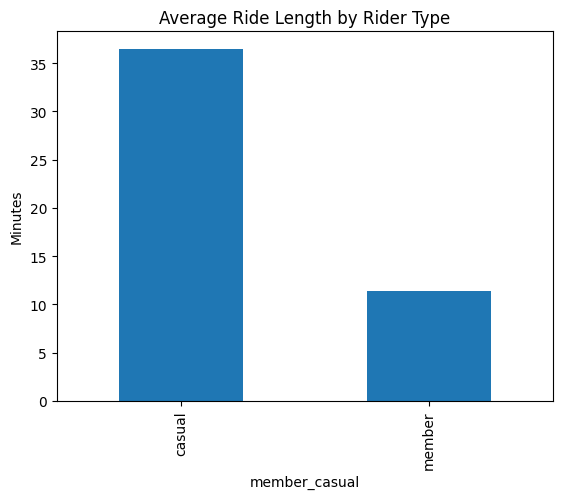

In [78]:
import matplotlib.pyplot as plt

df.groupby('member_casual')['ride_length_minutes'].mean().plot(kind='bar')
plt.title('Average Ride Length by Rider Type')
plt.ylabel('Minutes')
plt.show()